In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('mst-benchmarks-sort-once.csv')

### MST Graph plots

In [ ]:
kruskaldata = df.loc[(df[' NodeCount'] == 5000) & (df['Algorithm'] == 'Kruskal')]
primdata = df.loc[(df[' NodeCount'] == 5000) & (df['Algorithm'] == 'Prim')]
kruskaldata = kruskaldata.drop_duplicates(" EdgeCount")
primdata = primdata.drop_duplicates(" EdgeCount")

In [85]:
primdata

,EdgeCount,MeanTime
6,25000,19.045489
22,3124375,17085.588640
30,12497500,76214.882535


In [86]:
kruskaldata

,EdgeCount,MeanTime
7,25000,252.175447
23,3124375,21763.501883
31,12497500,45766.822857


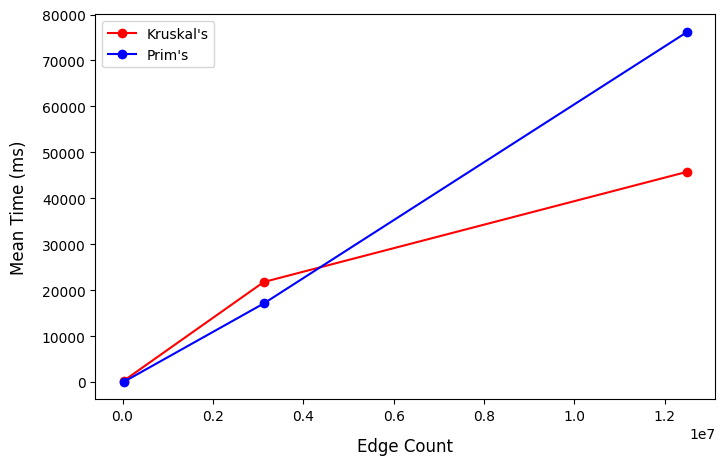

In [87]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.set_xlabel("Edge Count", fontsize=12, labelpad=10)
ax.set_ylabel("Mean Time (ms)", fontsize=12, labelpad=10)

ax.plot(
    kruskaldata[" EdgeCount"],
    kruskaldata[" MeanTime"],
    marker="o",
    color="red",
    linestyle="-",
    label="Kruskal's",
)
ax.plot(
    primdata[" EdgeCount"],
    primdata[" MeanTime"],
    marker="o",
    color="blue",
    linestyle="-",
    label="Prim's",
)
ax.legend(loc="upper left", fontsize=10, frameon=True)

> **Note that**: The Kruskal's version should run slower on Dense Graph due to the `O(ELgE)` vs `O((V+E)LgV)` however due to the caching of sorted list so it doesn't sort unless it really has to, reduced overhead and thus faster execution.

## Single Source Shortest Path

In [88]:
df = pd.read_csv('general-sssp-benchmarks.csv')
dijkstradata = df.drop_duplicates(' EdgeCount')
dijkstradata = dijkstradata.loc[df[' NodeCount'] == 5000]

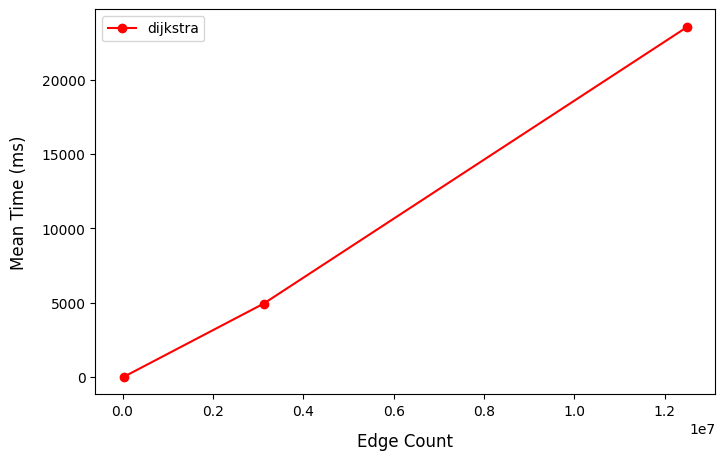

In [89]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.set_xlabel("Edge Count", fontsize=12, labelpad=10)
ax.set_ylabel("Mean Time (ms)", fontsize=12, labelpad=10)

ax.plot(
    dijkstradata[" EdgeCount"],
    dijkstradata[" MeanTime"],
    marker="o",
    color="red",
    linestyle="-",
    label="dijkstra",
)
ax.legend(loc="upper left", fontsize=10, frameon=True)

## Dijkstra vs DAG SSSP

In [130]:
df = pd.read_csv('general-sssp-benchmarks.csv')
dijkstradata = df.loc[(df[' Distribution'] == ' DAG'), [' NodeCount', ' EdgeCount', ' MeanTime']]
dijkstradata = dijkstradata.drop_duplicates(' EdgeCount').sort_values(' EdgeCount')


df = pd.read_csv('dag-sssp-benchmarks.csv')
dagdata = df.loc[(df[ 'Algorithm'] == 'DAG-Topo'), [' NodeCount', ' EdgeCount', ' MeanTime']]
dagdata = dagdata.drop_duplicates(' EdgeCount').sort_values(' EdgeCount')


In [127]:
dijkstradata

,NodeCount,EdgeCount,MeanTime
0,500,2500,0.547706
1,1000,5000,1.327098
2,2500,12500,2.899000
3,5000,25000,3.431187


In [131]:
dagdata

,NodeCount,EdgeCount,MeanTime
8,1000,5000,3.624951
0,2500,12500,2.580473
1,5000,25000,4.805695
2,10000,50000,13.032847
11,20000,100000,28.419404
12,100000,500000,196.004681


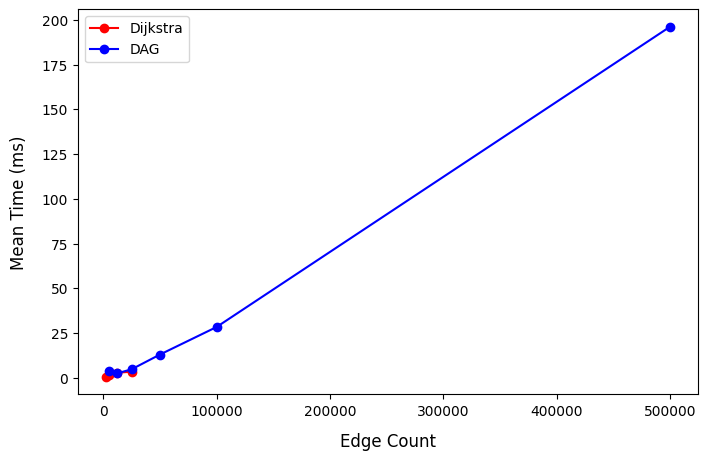

In [132]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.set_xlabel("Edge Count", fontsize=12, labelpad=10)
ax.set_ylabel("Mean Time (ms)", fontsize=12, labelpad=10)

ax.plot(
    dijkstradata[" EdgeCount"],
    dijkstradata[" MeanTime"],
    marker="o",
    color="red",
    linestyle="-",
    label="Dijkstra",
)
ax.plot(
    dagdata[" EdgeCount"],
    dagdata[" MeanTime"],
    marker="o",
    color="blue",
    linestyle="-",
    label="DAG",
)
ax.legend(loc="upper left", fontsize=10, frameon=True)